In [ ]:
# CELL 1 — Setup & Config (Colab)
# Mục tiêu: chuẩn bị môi trường cho bài RSI (crawling crypto → tiền xử lý → backtest).
# Lý do chọn: dùng ccxt để lấy OHLCV trực tiếp từ sàn (Binance mặc định).

# 1) Cài đặt & import
!pip -q install ccxt==4.* pandas numpy matplotlib pytz

import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pytz, sys, platform, math, time, datetime as dt

# 2) Cấu hình thí nghiệm (có thể chỉnh)
EXCHANGE_NAME = "binance"     # sàn để crawl
SYMBOL        = "BTC/USDT"    # cặp crypto
TIMEFRAME     = "1d"          # khung thời gian
START_DATE    = "2019-09-01"  # ngày bắt đầu crawl (UTC)
END_DATE      = None          # để None = đến hiện tại
TZ            = "UTC"         # chuẩn hóa múi giờ (pipeline Phase 1)

# Tham số phí/slippage cho backtest Phase 1 (đơn giản, tính theo bps)
FEE_BPS       = 5             # 5 bps = 0.05% mỗi lần vào/ra
SLIPPAGE_BPS  = 2             # 2 bps = 0.02%
START_CASH    = 10_000

# 3) Thiết lập hiển thị & reproducibility
pd.options.display.width = 160
pd.options.display.max_columns = 20
np.set_printoptions(suppress=True)
np.random.seed(42)

print("== ENV INFO ==")
print("Python :", sys.version.split()[0], "| Platform:", platform.platform())
print("ccxt   :", ccxt.__version__)
print("Symbol :", SYMBOL, "| Timeframe:", TIMEFRAME)
print("Start  :", START_DATE, "| End:", END_DATE or "now (UTC)")
print("Fees   :", f"{FEE_BPS} bps", "| Slippage:", f"{SLIPPAGE_BPS} bps")
print("TZ     :", TZ)

# ✅ Tiếp theo (Cell 2): viết hàm crawl OHLCV bằng ccxt (không dùng dữ liệu tĩnh),
# trả về DataFrame chuẩn Phase 1: index=timestamp(UTC), cột ['open','high','low','close','volume'].


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.6/130.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 641.1/641.1 kB 27.9 MB/s eta 0:00:00
== ENV INFO ==
Python : 3.12.12 | Platform: Linux-6.6.105+-x86_64-with-glibc2.35
ccxt   : 4.5.13
Symbol : BTC/USDT | Timeframe: 1d
Start  : 2019-09-01 | End: now (UTC)
Fees   : 5 bps | Slippage: 2 bps
TZ     : UTC


In [ ]:
# CELL 2B — Crawl OHLCV RAW với fallback nhiều sàn (không tiền xử lý)
# Thử lần lượt: binance, okx, kraken, kucoin, coinbase, bitfinex, gateio
# Output: df_raw_ohlcv (index=datetime UTC), cột: ['timestamp','open','high','low','close','volume']

import time
import pandas as pd
import numpy as np
import ccxt

FALLBACK_EXCHANGES = ["binance", "okx", "kraken", "kucoin", "coinbase", "bitfinex", "gateio"]

def pick_symbol_from_markets(ex, preferred=("BTC/USDT","BTC/USD")):
    ex.load_markets()
    for s in preferred:
        if s in ex.markets:
            return s
    # nếu không có các cặp ưa thích, chọn cặp BTC/* đầu tiên có OHLCV
    for s, m in ex.markets.items():
        if ("BTC" in s or "XBT" in s) and m.get("active", True):
            return s
    raise RuntimeError("Không tìm được symbol BTC/* phù hợp trên sàn này.")

def crawl_ohlcv_raw_any(timeframe, start_date, end_date=None, limit_per_call=1000):
    since_ms = pd.Timestamp(start_date, tz="UTC").value // 10**6
    until_ms = (pd.Timestamp.utcnow().value // 10**6) if end_date is None else pd.Timestamp(end_date, tz="UTC").value // 10**6

    for ex_id in FALLBACK_EXCHANGES:
        try:
            ex = getattr(ccxt, ex_id)({"enableRateLimit": True})
            symbol = pick_symbol_from_markets(ex)
            print(f"→ Thử sàn: {ex_id} | symbol: {symbol}")
            step_ms = ex.parse_timeframe(timeframe) * 1000

            all_parts, calls = [], 0
            cursor = since_ms

            while True:
                batch = ex.fetch_ohlcv(symbol, timeframe=timeframe, since=cursor, limit=limit_per_call)
                calls += 1
                if not batch:
                    break
                part = pd.DataFrame(batch, columns=["timestamp","open","high","low","close","volume"])
                all_parts.append(part)
                next_ms = int(part["timestamp"].iloc[-1]) + step_ms
                if next_ms > until_ms:
                    break
                cursor = next_ms
                time.sleep(ex.rateLimit / 1000)

            if not all_parts:
                print(f"⚠️ Không lấy được dữ liệu từ {ex_id}, thử sàn tiếp theo…")
                continue

            raw = pd.concat(all_parts, ignore_index=True)
            raw["dt_utc"] = pd.to_datetime(raw["timestamp"], unit="ms", utc=True)
            df_raw_ohlcv = raw.set_index("dt_utc")

            print("== RAW OHLCV DOWNLOADED ==")
            print("Exchange  :", ex_id)
            print("Symbol    :", symbol)
            print("Rows      :", len(df_raw_ohlcv))
            print("Range UTC :", df_raw_ohlcv.index.min(), "→", df_raw_ohlcv.index.max())
            print("API calls :", calls)
            return df_raw_ohlcv, ex_id, symbol

        except Exception as e:
            print(f"✖ {ex_id} lỗi: {type(e).__name__}: {e}. Thử sàn tiếp theo…")
            continue

    raise RuntimeError("Tất cả sàn trong fallback đều thất bại. Hãy đổi mạng/VPN hoặc thử timeframe/ khoảng thời gian khác.")

# GỌI HÀM (dùng TIMEFRAME, START_DATE, END_DATE đã đặt ở Cell 1)
df_raw_ohlcv, USED_EXCHANGE, USED_SYMBOL = crawl_ohlcv_raw_any(
    timeframe=TIMEFRAME,
    start_date=START_DATE,
    end_date=END_DATE,
    limit_per_call=1000
)

# Xem vài dòng đầu/cuối (thô)
display(df_raw_ohlcv.head(5))
display(df_raw_ohlcv.tail(5))


✖ binance lỗi: ExchangeNotAvailable: binance GET https://api.binance.com/api/v3/exchangeInfo 451  {
  "code": 0,
  "msg": "Service unavailable from a restricted location according to 'b. Eligibility' in https://www.binance.com/en/terms. Please contact customer service if you believe you received this message in error."
}. Thử sàn tiếp theo…
→ Thử sàn: okx | symbol: BTC/USDT
== RAW OHLCV DOWNLOADED ==
Exchange  : okx
Symbol    : BTC/USDT
Rows      : 2251
Range UTC : 2019-09-01 00:00:00+00:00 → 2025-10-29 00:00:00+00:00
API calls : 8


,timestamp,open,high,low,close,volume
dt_utc,,,,,,
2019-09-01 00:00:00+00:00,1567296000000,9589.1,9822.8,9519.2,9733.5,6076.788464
2019-09-02 00:00:00+00:00,1567382400000,9733.5,10450.0,9717.3,10343.8,16994.528201
2019-09-03 00:00:00+00:00,1567468800000,10345.0,10780.0,10269.7,10614.1,20903.142385
2019-09-04 00:00:00+00:00,1567555200000,10614.2,10806.5,10372.8,10562.2,16492.537402
2019-09-05 00:00:00+00:00,1567641600000,10562.2,10650.0,10450.0,10562.1,11011.121248


,timestamp,open,high,low,close,volume
dt_utc,,,,,,
2025-10-25 00:00:00+00:00,1761350400000,111009.9,111950.0,110663.3,111650.0,2966.226549
2025-10-26 00:00:00+00:00,1761436800000,111650.0,115590.0,111250.2,114554.6,5405.328157
2025-10-27 00:00:00+00:00,1761523200000,114555.7,116400.0,113850.0,114111.7,8251.601714
2025-10-28 00:00:00+00:00,1761609600000,114111.8,116100.0,112200.0,112892.9,7869.525592
2025-10-29 00:00:00+00:00,1761696000000,112892.9,112975.0,112084.7,112405.7,847.524666


In [ ]:
# CELL 3 — Standardize & Integrity Checks
# Input : df_raw_ohlcv (Cell 2B)
# Output: df (index=UTC datetime, cols=['open','high','low','close','volume']) + report nhanh

import pandas as pd
import numpy as np

# 1) Giữ đúng cột & ép kiểu
df = df_raw_ohlcv.copy()
keep = ["open","high","low","close","volume"]
df = df[keep].apply(pd.to_numeric, errors="coerce")
df = df.dropna(subset=["open","high","low","close"])
df = df[df["close"] > 0]

# 2) Đảm bảo index thời gian UTC, tăng dần, loại trùng
assert isinstance(df.index, pd.DatetimeIndex), "Index chưa phải DatetimeIndex."
if df.index.tz is None:
    df = df.tz_localize("UTC")
else:
    df = df.tz_convert("UTC")

df = df.sort_index()
dups = int(df.index.duplicated().sum())
if dups:
    df = df[~df.index.duplicated(keep="last")]

# 3) Thống kê độ phủ & missing (1D)
expected = pd.date_range(df.index.min(), df.index.max(), freq="D", tz="UTC")
missing_days = len(set(expected) - set(df.index))

# 4) In báo cáo
print("== CLEAN DATA REPORT ==")
print("Rows        :", len(df))
print("Range (UTC) :", df.index.min(), "→", df.index.max())
print("Duplicates  :", dups)
print("Missing 1D  :", missing_days)
print("NA in price :", int(df[keep].isna().sum().sum()))
print("Return mean/std:", df["close"].pct_change().mean(), df["close"].pct_change().std())

# 5) Xem nhanh đầu/cuối
display(df.head(3))
display(df.tail(3))


== CLEAN DATA REPORT ==
Rows        : 2251
Range (UTC) : 2019-09-01 00:00:00+00:00 → 2025-10-29 00:00:00+00:00
Duplicates  : 0
Missing 1D  : 0
NA in price : 0
Return mean/std: 0.001627913941093296 0.032549206611501735


,open,high,low,close,volume
dt_utc,,,,,
2019-09-01 00:00:00+00:00,9589.1,9822.8,9519.2,9733.5,6076.788464
2019-09-02 00:00:00+00:00,9733.5,10450.0,9717.3,10343.8,16994.528201
2019-09-03 00:00:00+00:00,10345.0,10780.0,10269.7,10614.1,20903.142385


,open,high,low,close,volume
dt_utc,,,,,
2025-10-27 00:00:00+00:00,114555.7,116400.0,113850.0,114111.7,8251.601714
2025-10-28 00:00:00+00:00,114111.8,116100.0,112200.0,112892.9,7869.525592
2025-10-29 00:00:00+00:00,112892.9,112975.0,112084.7,112405.7,847.524666


In [ ]:
# CELL 4 — SMA Crossover (short vs long) + tín hiệu đã shift (NO LOOKAHEAD)
# Input : df (Cell 3) — index UTC, cols: ['open','high','low','close','volume']
# Output: sma_df — index UTC, cols: ['close','ma_fast','ma_slow','signal'] (signal đã shift)

import pandas as pd
import numpy as np

# 1) Tham số SMA
FAST = 20
SLOW = 50
assert FAST < SLOW, "FAST phải nhỏ hơn SLOW"

# 2) Tính SMA & tạo tín hiệu
sma_df = pd.DataFrame(index=df.index)
sma_df["close"]    = df["close"]
sma_df["ma_fast"]  = sma_df["close"].rolling(FAST, min_periods=FAST).mean()
sma_df["ma_slow"]  = sma_df["close"].rolling(SLOW, min_periods=SLOW).mean()

# Tín hiệu long-only: 1 khi MA_fast > MA_slow, ngược lại 0
raw_signal = (sma_df["ma_fast"] > sma_df["ma_slow"]).astype(int)

# DỊCH 1 BAR để tránh lookahead (khớp lệnh tại T+1)
sma_df["signal"] = raw_signal.shift(1).fillna(0).astype(int)

# 3) Sanity checks
valid_mask = sma_df["ma_slow"].notna()  # chỉ sau khi đủ cửa sổ SLOW
sig = sma_df.loc[valid_mask, "signal"]

print("== SMA CROSSOVER SUMMARY ==")
print(f"FAST={FAST} | SLOW={SLOW}")
print("Samples usable (after warmup):", int(valid_mask.sum()))
print("Signal counts {0,1}:", sig.value_counts().to_dict())

switches = int((sig != sig.shift(1)).sum())
print("Signal switches (≈ #trades):", switches)

# Xem 10 lần chuyển trạng thái đầu tiên
first_sw = sma_df.loc[valid_mask & (sig != sig.shift(1)), ["close","ma_fast","ma_slow","signal"]].head(10)
display(first_sw)

# Xem vài dòng đầu/cuối để chắc dữ liệu hợp lệ
display(sma_df.head(3))
display(sma_df.tail(3))


== SMA CROSSOVER SUMMARY ==
FAST=20 | SLOW=50
Samples usable (after warmup): 2202
Signal counts {0,1}: {1: 1231, 0: 971}
Signal switches (≈ #trades): 51


,close,ma_fast,ma_slow,signal
dt_utc,,,,
2019-10-20 00:00:00+00:00,8219.6,8199.700,9146.258,0
2019-11-06 00:00:00+00:00,9339.1,8764.270,8662.972,1
2019-11-25 00:00:00+00:00,7109.1,8311.105,8461.010,0
2020-01-09 00:00:00+00:00,7820.0,7400.495,7324.242,1
2020-03-06 00:00:00+00:00,9133.1,9259.300,9307.454,0
2020-04-20 00:00:00+00:00,6828.4,6963.465,6869.856,1
2020-06-30 00:00:00+00:00,9136.5,9339.935,9419.136,0
2020-07-28 00:00:00+00:00,10908.0,9509.755,9405.348,1
2020-09-10 00:00:00+00:00,10337.1,11045.260,11209.712,0


,close,ma_fast,ma_slow,signal
dt_utc,,,,
2019-09-01 00:00:00+00:00,9733.5,NaN,NaN,0
2019-09-02 00:00:00+00:00,10343.8,NaN,NaN,0
2019-09-03 00:00:00+00:00,10614.1,NaN,NaN,0


,close,ma_fast,ma_slow,signal
dt_utc,,,,
2025-10-27 00:00:00+00:00,114111.7,112031.000,114263.132,0
2025-10-28 00:00:00+00:00,112892.9,111510.440,114279.722,0
2025-10-29 00:00:00+00:00,112405.7,111047.905,114296.998,0


### Cell 5 — Backtest SMA(20,50) trên BTC & So sánh Buy&Hold

**Kết quả (BTC/USDT, 1D | cùng khoảng warm-up):**
- **SMA(20,50)**  
  - Cumulative Return: **6.623**  
  - Sharpe (daily, 252): **0.822**  
  - Max Drawdown: **−0.552**  
  - Trades: **50**, Exposure: **55.90%**
- **Buy&Hold**  
  - Cumulative Return: **12.703**  
  - Sharpe (daily, 252): **0.843**  
  - Max Drawdown: **−0.766**  
  - Trades: **1**, Exposure: **99.91%**

**Kiểm chứng:**
- `pos_prev == signal.shift(1)` → **No-lookahead OK**.  
- Equity plot: hiển thị SMA vs Buy&Hold trên cùng trục thời gian.

**Nhận xét ngắn:**
- SMA(20,50) giúp **giảm MDD** so với Buy&Hold (−55% vs −77%) nhờ thoát khi mất xu hướng.  
- Tổng lợi nhuận **thấp hơn** Buy&Hold do **exposure ~56%** và hiệu ứng whipsaw trong giai đoạn đi ngang.  
- Sharpe xấp xỉ Buy&Hold → chiến lược có tính phòng thủ tốt hơn nhưng bỏ lỡ một phần bull-run.

**Hướng tiếp theo:** thử grid (Cell 6) tối ưu `(FAST,SLOW)` và kiểm tra out-of-sample/walk-forward để tránh overfit.


=== SMA(FAST=20, SLOW=50) REPORT ===
Cumulative Return: 6.623498
Sharpe (daily,252): 0.821780
Max Drawdown: -0.551762
Trades: 50
Exposure %: 55.903724

=== BUY & HOLD (same warmup) REPORT ===
Cumulative Return: 12.702929
Sharpe (daily,252): 0.842683
Max Drawdown: -0.766257
Trades: 1
Exposure %: 99.909173


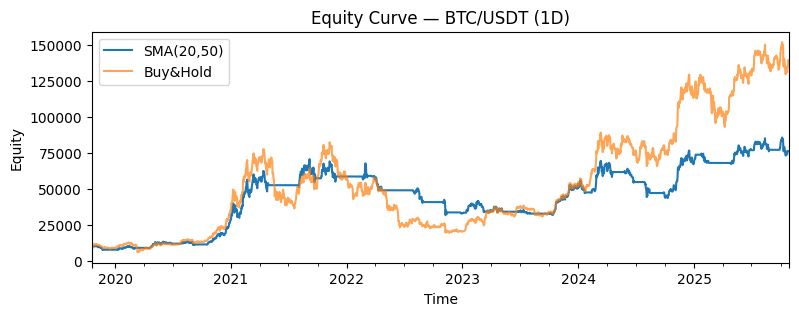


Rows with trades: 50


,close,ret,pos_prev,pos,trade,net_ret,equity
dt_utc,,,,,,,
2019-11-06 00:00:00+00:00,9339.1,0.003751,0.0,1.0,1.0,-0.000700,9993.000000
2019-11-25 00:00:00+00:00,7109.1,0.029916,1.0,0.0,1.0,0.029216,7601.690947
2020-01-09 00:00:00+00:00,7820.0,-0.029138,0.0,1.0,1.0,-0.000700,7596.369763
2020-03-06 00:00:00+00:00,9133.1,0.008681,1.0,0.0,1.0,0.007981,8865.761861
2020-04-20 00:00:00+00:00,6828.4,-0.041022,0.0,1.0,1.0,-0.000700,8859.555828
2020-06-30 00:00:00+00:00,9136.5,-0.005692,1.0,0.0,1.0,-0.006392,11845.871030
2020-07-28 00:00:00+00:00,10908.0,-0.011177,0.0,1.0,1.0,-0.000700,11837.578920
2020-09-10 00:00:00+00:00,10337.1,0.011567,1.0,0.0,1.0,0.010867,11210.264038


In [ ]:
# CELL 5 — Backtest SMA Crossover (stateful by design) + kiểm chứng + so sánh BH

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0) Chỉ backtest trên phần đã đủ warmup (SLOW)
valid_mask = sma_df["ma_slow"].notna()
sig_df = sma_df.loc[valid_mask, ["close", "signal"]].copy()
bh_df  = pd.DataFrame({"close": sig_df["close"], "signal": 1}, index=sig_df.index)
bh_df["signal"] = bh_df["signal"].shift(1).fillna(0).astype(int)  # BH cũng khớp T+1 cho công bằng

class Backtester:
    def __init__(self, fee_bps=5, slippage_bps=2, start_cash=10_000):
        self.fee = fee_bps / 10_000.0
        self.slip = slippage_bps / 10_000.0
        self.start_cash = float(start_cash)

    def run(self, df_sig: pd.DataFrame):
        df = df_sig.copy()
        assert {"close","signal"} <= set(df.columns), "Cần 'close' và 'signal'"
        df["ret"] = df["close"].pct_change().fillna(0.0)

        # Vị thế áp dụng tại t là signal_{t-1}
        df["pos"] = df["signal"].astype(float).fillna(0)
        df["pos_prev"] = df["pos"].shift(1).fillna(0.0)
        df["trade"] = (df["pos"] - df["pos_prev"]).abs()

        gross = df["pos_prev"] * df["ret"]
        cost  = df["trade"] * (self.fee + self.slip)
        df["net_ret"] = gross - cost
        df["equity"]  = (1 + df["net_ret"]).cumprod() * START_CASH

        daily  = df["net_ret"].replace([np.inf,-np.inf],0).fillna(0)
        cumret = (1 + daily).prod() - 1
        sharpe = np.sqrt(252) * daily.mean() / (daily.std(ddof=0) + 1e-12)
        roll   = (1 + daily).cumprod()
        mdd    = (roll / roll.cummax() - 1).min()

        report = {
            "Cumulative Return": float(cumret),
            "Sharpe (daily,252)": float(sharpe),
            "Max Drawdown": float(mdd),
            "Trades": int((df["trade"]>0).sum()),
            "Exposure %": float((df["pos_prev"]>0).mean()*100),
        }
        return df, report

bt = Backtester(fee_bps=FEE_BPS, slippage_bps=SLIPPAGE_BPS, start_cash=START_CASH)

# 1) SMA Crossover
res_sma, rep_sma = bt.run(sig_df)
print("=== SMA(FAST={}, SLOW={}) REPORT ===".format(FAST, SLOW))
for k,v in rep_sma.items():
    print(f"{k}: {v:.6f}" if isinstance(v,float) else f"{k}: {v}")

# 2) Kiểm chứng no-lookahead: pos_prev phải đúng bằng signal.shift(1)
sig_shifted = sig_df["signal"].shift(1).reindex(res_sma.index).fillna(0).astype(float)
assert np.allclose(res_sma["pos_prev"].values, sig_shifted.values), "Nghi ngờ lookahead!"

# 3) Benchmark Buy&Hold (cùng khoảng warmup)
res_bh, rep_bh = bt.run(bh_df)
print("\n=== BUY & HOLD (same warmup) REPORT ===")
for k,v in rep_bh.items():
    print(f"{k}: {v:.6f}" if isinstance(v,float) else f"{k}: {v}")

# 4) Plot equity
plt.figure(figsize=(9,3))
res_sma["equity"].plot(label=f"SMA({FAST},{SLOW})")
res_bh["equity"].plot(alpha=0.7, label="Buy&Hold")
plt.title("Equity Curve — BTC/USDT (1D)")
plt.xlabel("Time"); plt.ylabel("Equity"); plt.legend(); plt.show()

# 5) Blotter — xem 8 giao dịch đầu
blotter = res_sma.loc[res_sma["trade"]>0, ["close","ret","pos_prev","pos","trade","net_ret","equity"]]
print("\nRows with trades:", len(blotter))
display(blotter.head(8))


### Cell 6 — Grid Search SMA (BTC) — Kết quả & Diễn giải

**Thiết lập:** FAST ∈ {5..60, step 5}, SLOW ∈ {50..250, step 10}, ràng buộc `SLOW−FAST ≥ 10`, loại nghiệm `Trades < 10`. Tín hiệu **shift +1** (T+1), phí/slip như Cell 1.

**Kết quả tốt nhất**
- **SMA(5,60)** → **Sharpe = 1.034**, **CumRet = 13.44**, **MDD = −0.450**, **Trades = 60**, **Exposure ≈ 56.02%**  
- Equity cho thấy SMA(5,60) **giảm drawdown** và duy trì hiệu suất ổn định hơn so với Buy&Hold trên cùng khoảng warm-up.

**Top 5 theo Sharpe (tóm tắt)**
- (5,60)  → Sharpe ~1.034,  CumRet ~13.44, MDD ~−0.450
- (5,100) → Sharpe ~1.028,  CumRet ~13.75, MDD ~−0.486
- (5,150) → Sharpe ~0.986,  CumRet ~11.28, MDD ~−0.471
- (5,50)  → Sharpe ~0.975,  CumRet ~11.31, MDD ~−0.528
- (5,160) → Sharpe ~0.975,  CumRet ~10.73, MDD ~−0.449

**Nhận xét ngắn**
- FAST rất nhỏ (5) + SLOW trung bình (60–100) cho Sharpe cao: vào sớm khi có trend, nhưng số lệnh tăng (chi phí cao hơn).  
- MDD tốt hơn đáng kể so với Buy&Hold nhờ thoát khi mất xu hướng.  
- **Cảnh báo:** tối ưu trên toàn mẫu có thể **overfit** → nên xác thực bằng **train/test theo thời gian** hoặc **walk-forward** trước khi sử dụng thực tế.


== BEST SMA BY SHARPE ==
FAST          5.000000
SLOW         60.000000
Sharpe        1.033700
CumRet       13.436434
MDD          -0.450105
Trades       60.000000
Exposure%    56.021898

Top 10 theo Sharpe:


,FAST,SLOW,Sharpe,CumRet,MDD,Trades,Exposure%
0,5,60,1.033700,13.436434,-0.450105,60,56.021898
1,5,100,1.028045,13.750442,-0.486342,30,62.128253
2,5,150,0.986263,11.281584,-0.471423,23,63.986679
3,5,50,0.974807,11.309961,-0.528148,64,55.131698
4,5,160,0.974622,10.732189,-0.449282,23,64.196941
5,5,90,0.961983,11.094449,-0.560581,52,60.545791
6,5,130,0.952544,10.027481,-0.399197,28,63.524976
7,20,60,0.935821,9.921479,-0.453727,44,56.888686
8,5,140,0.929028,9.350606,-0.440483,26,64.015152
9,5,210,0.923999,9.097170,-0.488129,23,67.433888


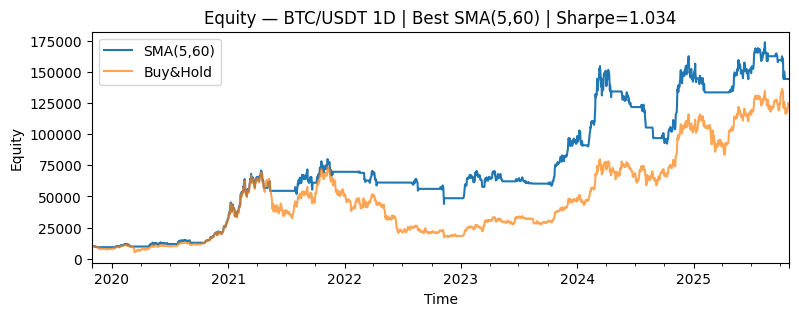

In [ ]:
# CELL 6 — Grid search SMA Crossover (tối ưu Sharpe)
# Mục tiêu: tìm (FAST, SLOW) tốt nhất theo Sharpe. Ràng buộc FAST < SLOW.
# Ghi chú: kết quả trên toàn mẫu có nguy cơ overfit → dùng để tham khảo/khởi tạo.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Lưới tham số (có thể chỉnh)
FAST_GRID = list(range(5, 61, 5))     # 5,10,...,60
SLOW_GRID = list(range(50, 251, 10))  # 50,60,...,250
GAP_MIN   = 10                        # yêu cầu SLOW - FAST >= GAP_MIN
MIN_TRADES = 20                  # loại nghiệm quá ít giao dịch

def run_sma_backtest(close: pd.Series, fast: int, slow: int):
    df_ = pd.DataFrame({"close": close})
    df_["ma_fast"] = df_["close"].rolling(fast, min_periods=fast).mean()
    df_["ma_slow"] = df_["close"].rolling(slow, min_periods=slow).mean()
    raw = (df_["ma_fast"] > df_["ma_slow"]).astype(int)
    sig = raw.shift(1).fillna(0).astype(int)
    valid = df_["ma_slow"].notna()
    sig_df = pd.DataFrame({"close": df_.loc[valid,"close"], "signal": sig.loc[valid]})

    # BH cùng khoảng warmup để công bằng
    bh_df = pd.DataFrame({"close": sig_df["close"], "signal": 1}, index=sig_df.index)
    bh_df["signal"] = bh_df["signal"].shift(1).fillna(0).astype(int)

    # dùng Backtester ở Cell 5
    res, rep = bt.run(sig_df)
    res_bh, rep_bh = bt.run(bh_df)
    return res, rep, res_bh, rep_bh

def metric_tuple(rep):
    return (
        float(rep["Sharpe (daily,252)"]),
        float(rep["Cumulative Return"]),
        float(rep["Max Drawdown"]),
        int(rep["Trades"]),
        float(rep["Exposure %"])
    )

rows = []
for f in FAST_GRID:
    for s in SLOW_GRID:
        if s - f < GAP_MIN:
            continue
        res, rep, _, _ = run_sma_backtest(df["close"], f, s)
        sharpe, cumret, mdd, trades, expo = metric_tuple(rep)
        rows.append({"FAST":f, "SLOW":s, "Sharpe":sharpe, "CumRet":cumret,
                     "MDD":mdd, "Trades":trades, "Exposure%":expo})

grid = pd.DataFrame(rows)
grid_f = grid[grid["Trades"] >= MIN_TRADES].sort_values("Sharpe", ascending=False)

# Kết quả tốt nhất
best = grid_f.iloc[0]
print("== BEST SMA BY SHARPE ==")
print(best[["FAST","SLOW","Sharpe","CumRet","MDD","Trades","Exposure%"]].to_string())

# Top 10
print("\nTop 10 theo Sharpe:")
display(grid_f.head(10).reset_index(drop=True))

# Vẽ equity của cấu hình tốt nhất (và Buy&Hold cùng khoảng)
best_fast, best_slow = int(best["FAST"]), int(best["SLOW"])
res_best, rep_best, res_bh_best, _ = run_sma_backtest(df["close"], best_fast, best_slow)

plt.figure(figsize=(9,3))
res_best["equity"].plot(label=f"SMA({best_fast},{best_slow})")
res_bh_best["equity"].plot(alpha=0.7, label="Buy&Hold")
plt.title(f"Equity — BTC/USDT 1D | Best SMA({best_fast},{best_slow}) | Sharpe={best['Sharpe']:.3f}")
plt.xlabel("Time"); plt.ylabel("Equity"); plt.legend(); plt.show()
